In [1]:
import pandas as pd
import ROOT
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.LHCb)
import numpy as np
import uproot
import apd
%matplotlib inline
plt.rcParams["figure.figsize"] = (12,10)


Welcome to JupyROOT 6.28/00


/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-04-26_20-20/linux-64/lib/python3.10/site-packages/mplhep/_deprecate.py:107: FutureWarning: 'LHCb' style is deprecated as it may change in the future. Please use 'LHCb1' (which is the same as currently 'LHCb') or 'LHCb2'.
  warnings.warn(self.message, category=self._warning, stacklevel=1)


In [2]:
config = "mc"
datatype = "2012"
eventtype = "13563002"
polarities = [ "magdown", "magup" ]
sign = "rs"
data_prefix =  "root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/output/"

In [3]:
## Gettting AnalysisData info 
# from apd import get_analysis_data
# dataset = get_analysis_data("sl", "rds_hadronic")
# files = dataset(config=config, datatype=datatype, eventtype=eventtype, polarity=polarities, sign=sign)
# rdf1 = ROOT.RDataFrame("SignalTuple/DecayTree", files)

In [22]:
def get_filenames(datatype, eventtype, sign):
        filenames = [ f"{data_prefix}/rds_final_{datatype}_{eventtype}_{polarity}_{sign}.root" 
                      for polarity in polarities ]
        return filenames
filenames = get_filenames(datatype, eventtype, sign)
print(filenames)
rdf = ROOT.RDataFrame("DecayTree", filenames)

['root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/output//rds_final_2012_13563002_magdown_rs.root', 'root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/output//rds_final_2012_13563002_magup_rs.root']


In [5]:
columns = ["q2_2", "q2_MC_2", "B_P", "B_PX", "B_PY", "B_PZ", "B_TRUEP_X", "B_TRUEP_Y", "B_TRUEP_Z", 
           "tauY_2", "Y_TRUETAU",    "Xc_MM", "BDT_3pi", "BDT_Ds", "BDT_Bs", "B_BKGCAT", "Xc_BKGCAT", 
           "Y_BKGCAT", "Xc_Selection"]
#print(set(columns) - set(rdf.GetColumnNames()))

In [6]:
df = pd.DataFrame(rdf.Cache(columns).AsNumpy()) 
qmin = -40.0
df = df[ (df["q2_2"] > qmin) & (df["q2_MC_2"] > qmin) & ( df["BDT_3pi"] >-0.0727)
        & (df["BDT_Ds"] >-0.0876) & (df["BDT_Bs"] >-0.0655)]
df = df[(df["Xc_Selection"] > 0)]

# W mass resolution

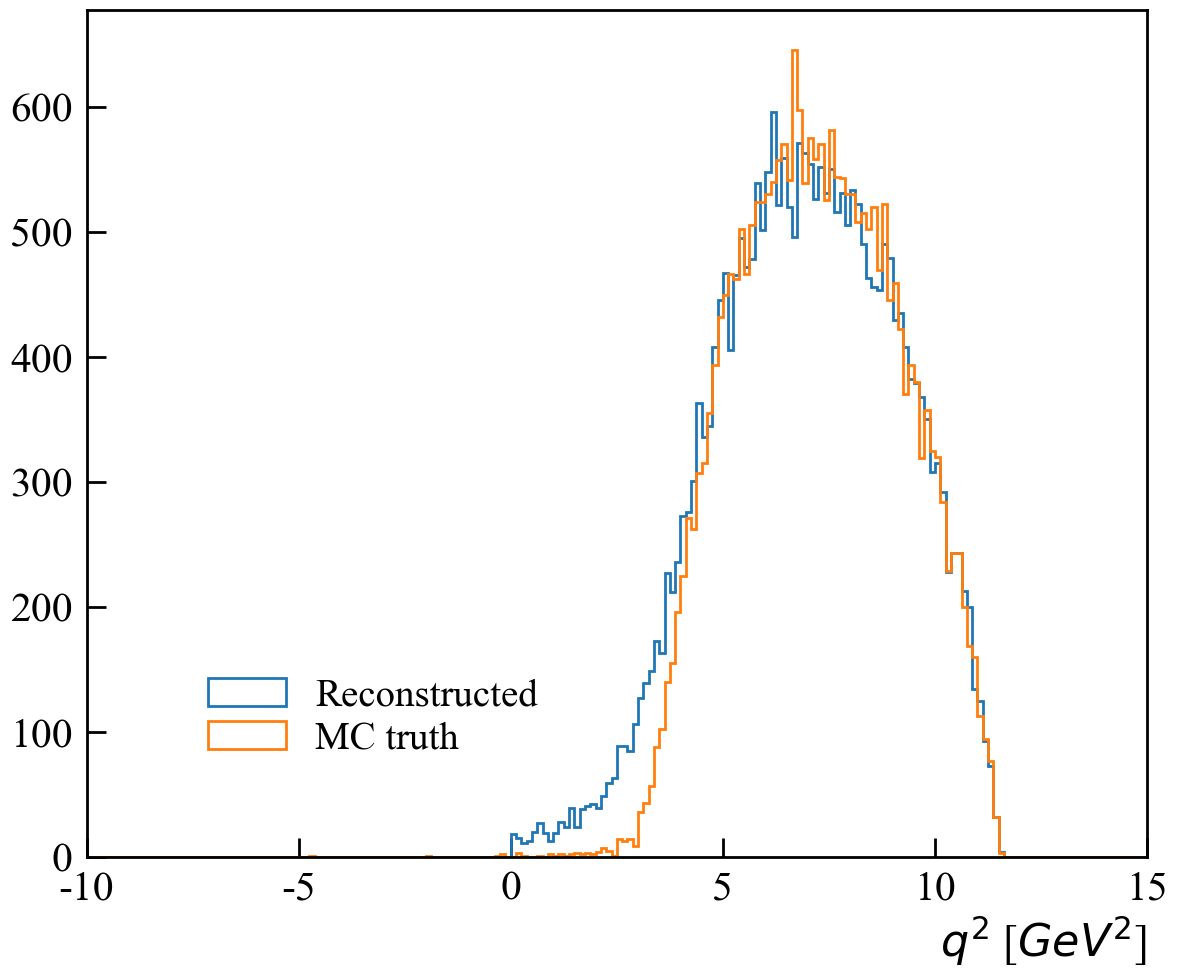

In [12]:
hrange=[-10, 15]
hbincount=200

count, bins, _ = plt.hist(df["q2_2"], label="Reconstructed", bins=hbincount, range=hrange, histtype='step')
plt.xlabel('$q^2$ [$GeV^2$]')
plt.xlim(bins[0], bins[-1])
plt.hist(df["q2_MC_2"], label="MC truth", bins=hbincount, range=hrange, histtype='step')
plt.legend(loc=[0.1, 0.1])
plt.savefig("signal_q2hist.png")

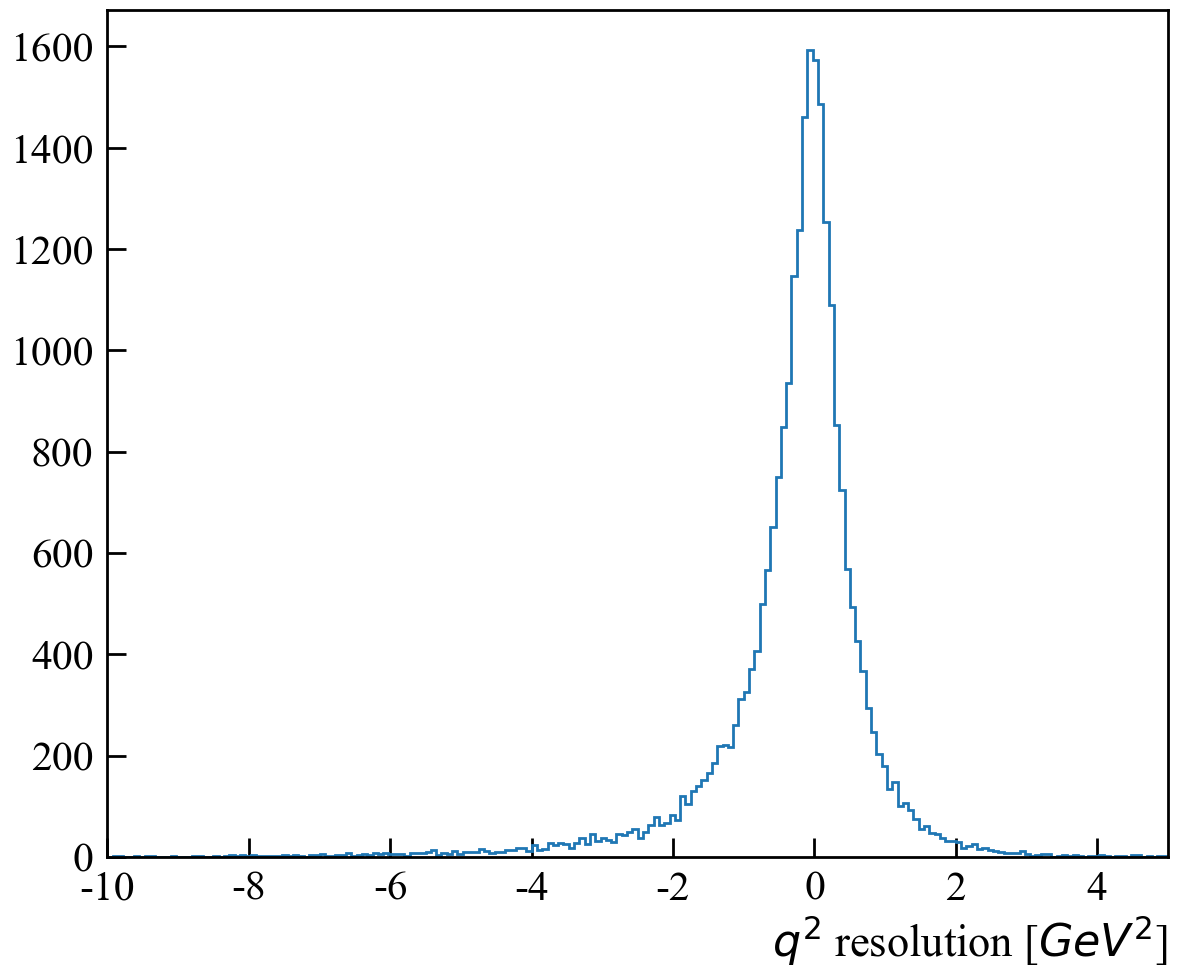

In [11]:
hrange=[-10, 5]
hbincount=200

qres = df["q2_2"] - df["q2_MC_2"]

count, bins, _ = plt.hist(qres, label="Resolution", bins=hbincount, range=hrange, histtype='step')
plt.xlabel('$q^2$ resolution [$GeV^2$]')
_ = plt.xlim(bins[0], bins[-1])
plt.savefig("signal_qres.png")

In [66]:
qres.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64

# Bs momentum resolution

In [13]:
np.max(np.abs(df["B_P"] - np.sqrt(np.square(df["B_PX"])  +  np.square(df["B_PY"]) + np.square(df["B_PZ"]))))

0.0

In [14]:
df["B_TRUEP"] =  np.sqrt(np.square(df["B_TRUEP_X"])  +  np.square(df["B_TRUEP_Y"]) + np.square(df["B_TRUEP_Z"]))

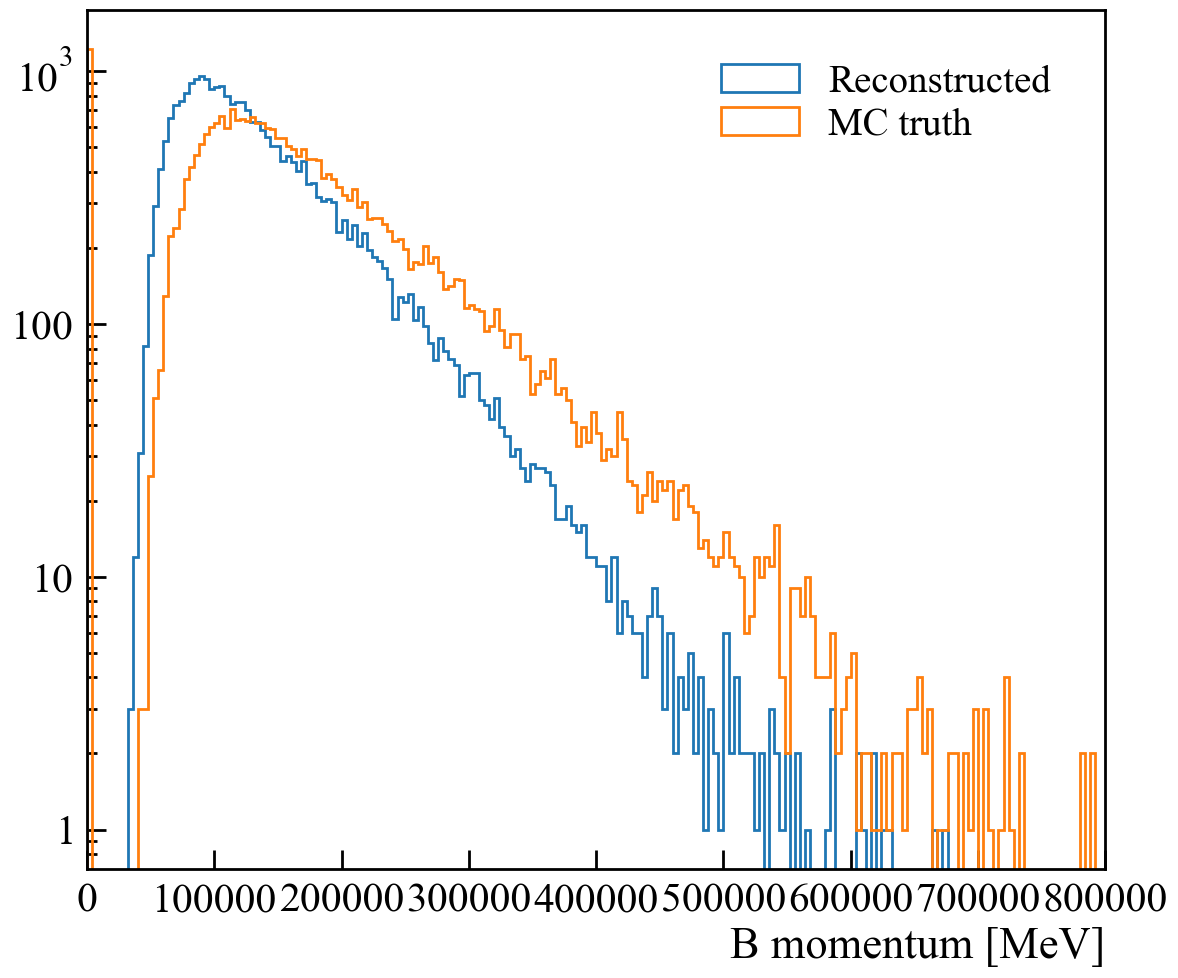

In [17]:
hrange=[0, 800000]
hbincount=200
count, bins, _ = plt.hist(df["B_P"], label="Reconstructed", bins=hbincount, range=hrange, histtype='step')
plt.xlabel('B momentum [MeV]')
plt.xlim(bins[0], bins[-1])
_ = plt.hist(df["B_TRUEP"], label="MC truth", bins=hbincount, range=hrange, histtype='step')
plt.legend(loc="best")
plt.yscale("log")
plt.savefig("signal_BP.png")

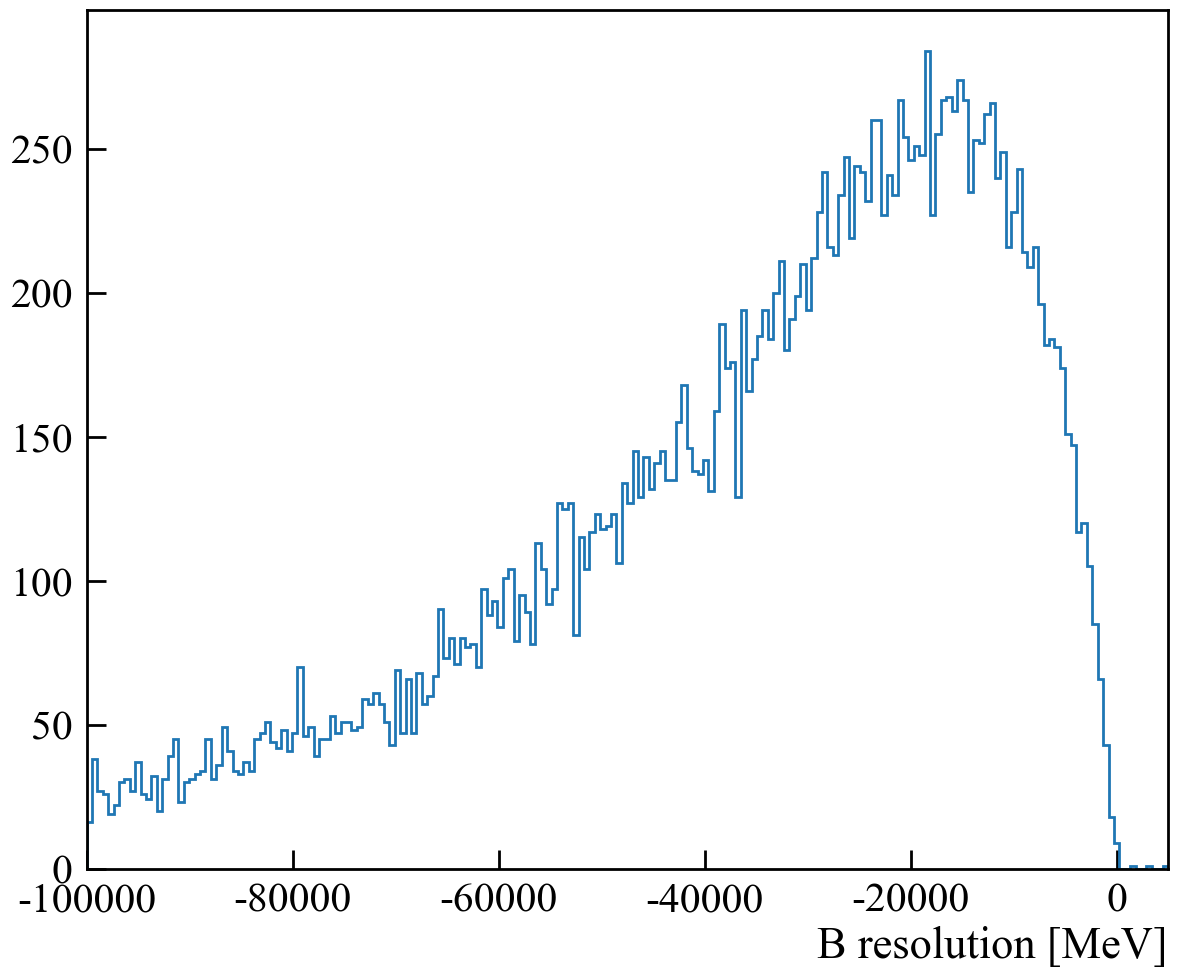

In [18]:

hrange=[-100000, 5000]
hbincount=200

bres = df["B_P"] - df["B_TRUEP"]

count, bins, _ = plt.hist(bres, label="B Resolution", bins=hbincount, range=hrange, histtype='step')
plt.xlabel('B resolution [MeV]')
_ = plt.xlim(bins[0], bins[-1])
plt.savefig("signal_BRes.png")

# Tau lifetime

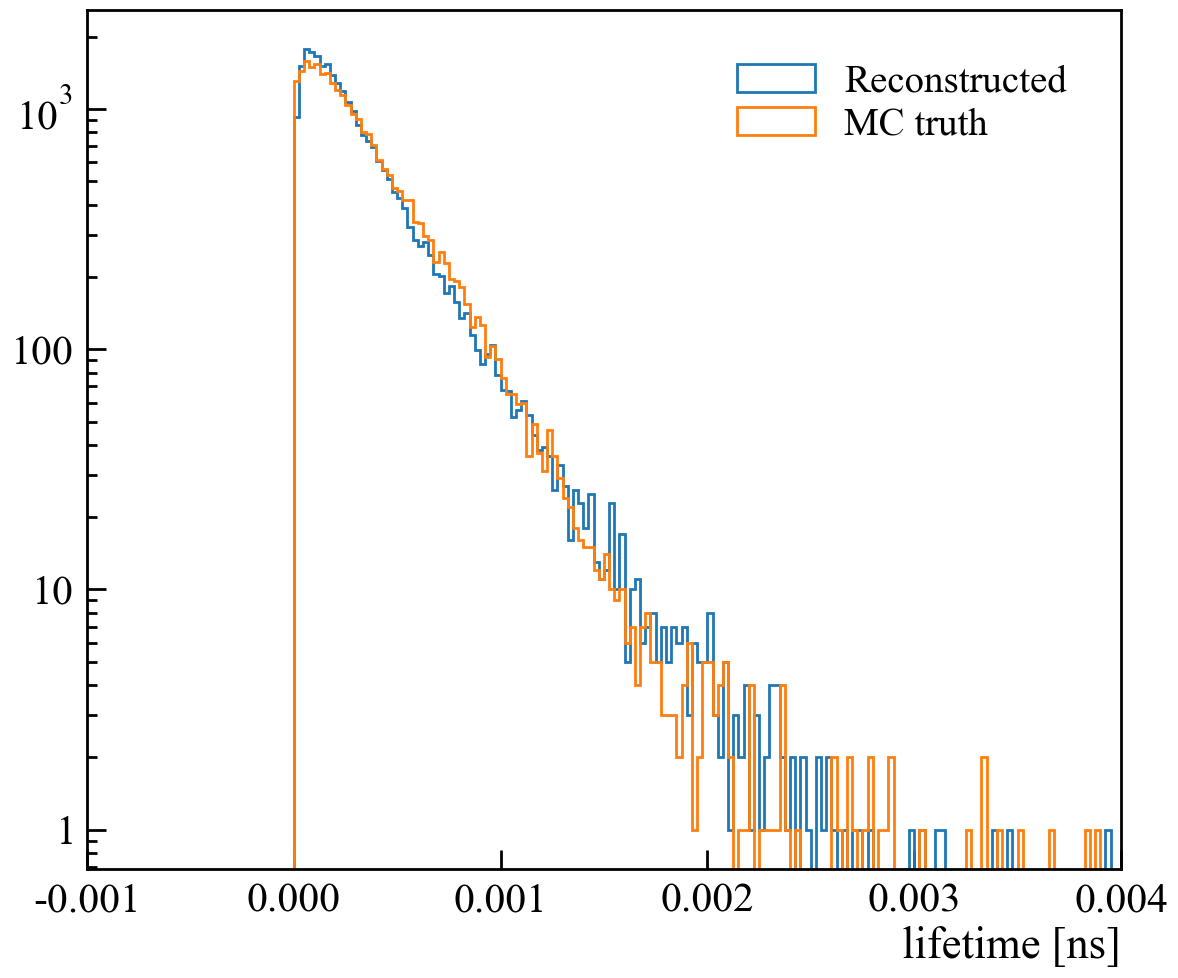

In [20]:

hrange=[-0.001, 0.004]
hbincount=200

count, bins, _ = plt.hist(df["tauY_2"], label="Reconstructed", bins=hbincount, range=hrange, histtype='step')
plt.xlabel('lifetime [ns]')
plt.xlim(bins[0], bins[-1])
plt.hist(df["Y_TRUETAU"], label="MC truth", bins=hbincount, range=hrange, histtype='step')
plt.legend(loc="best")
plt.yscale("log")
plt.savefig("signal_TauLifetime.png")

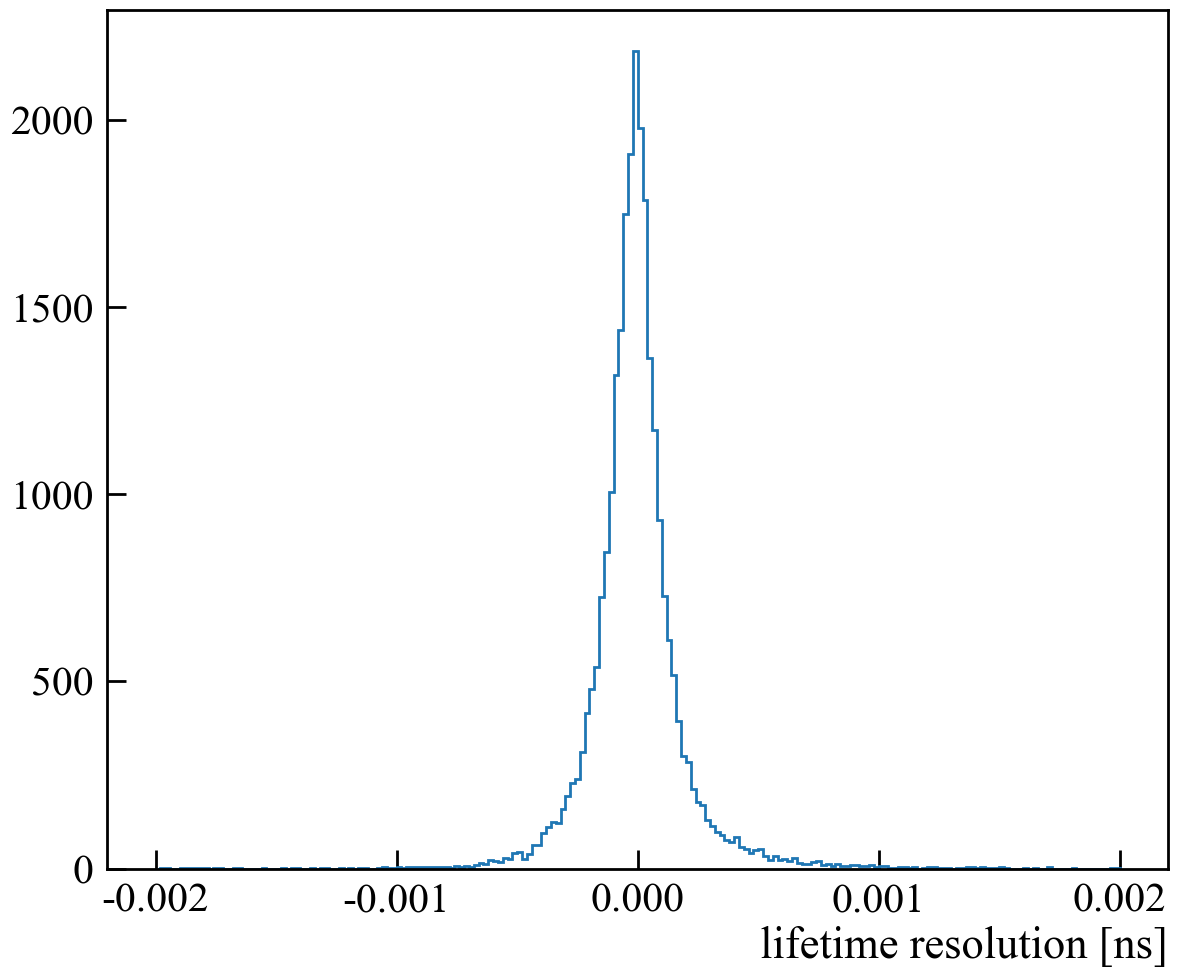

In [21]:

hrange=[-0.002, 0.002]
hbincount=200
taures = df["tauY_2"] - df["Y_TRUETAU"]
taureshist, tauresbins, _ = plt.hist(taures, label="Resolution", bins=hbincount, range=hrange, histtype='step')
_ = plt.xlabel('lifetime resolution [ns]')
tauresmid = ( tauresbins[1:] + tauresbins[:-1] )/2
#plt.yscale("log")

plt.savefig("signal_TauRes.png")

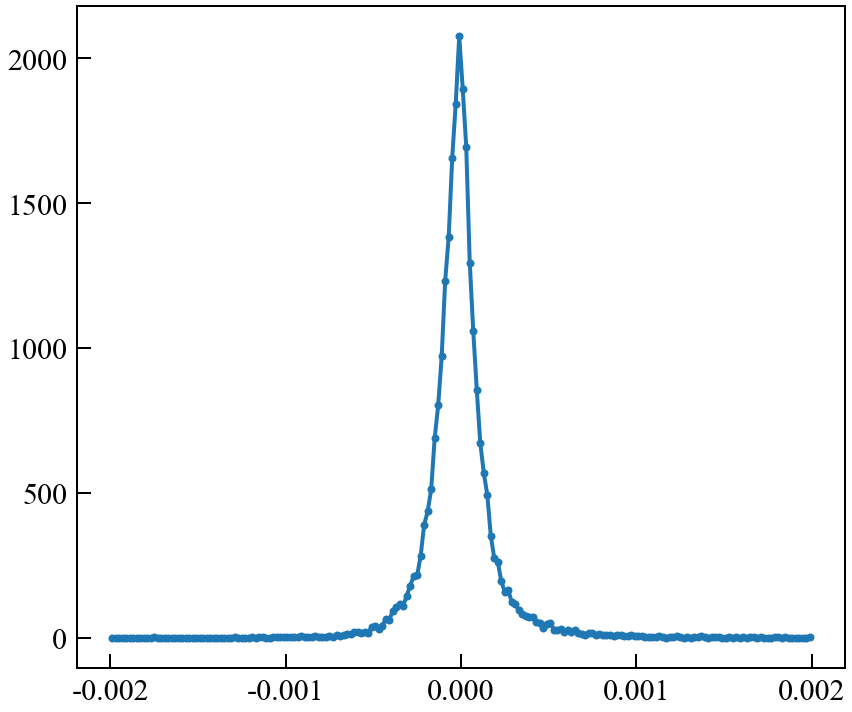

In [24]:
plt.plot(tauresmid, taureshist)

# Cut checks

In [25]:
dcheck = pd.DataFrame(rdf.Cache(
    [ "BDT_3pi", "BDT_Ds", "BDT_Bs", "B_BKGCAT", "Xc_BKGCAT", "Y_BKGCAT", "Xc_Selection", "Xc_MM"]
).AsNumpy())

<AxesSubplot:>

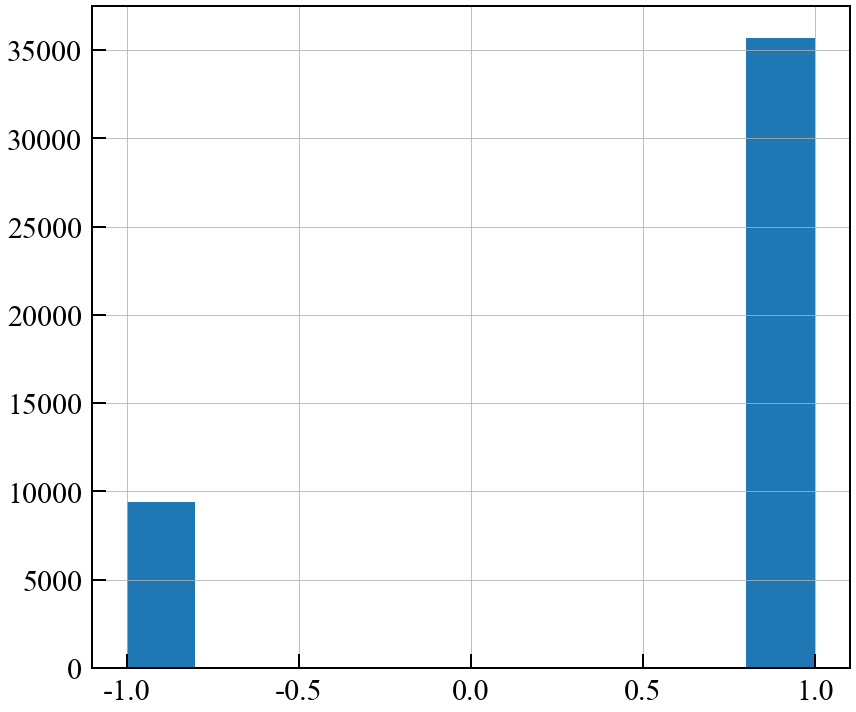

In [26]:
dcheck[  ( (dcheck["Xc_MM"] - 1968.0 < 20) ) &  ( (dcheck["Xc_BKGCAT"] == 0) | (dcheck["Xc_BKGCAT"] == 50) ) & (dcheck["Y_BKGCAT"] == 50)  & (dcheck["B_BKGCAT"] == 50) ]["Xc_Selection"].hist()


In [27]:
d = dcheck[(dcheck["Xc_Selection"] > 0)]
all(((d["Xc_MM"] - 1968.0 < 20) ) &  ( (d["Xc_BKGCAT"] == 0) | (d["Xc_BKGCAT"] == 50) ) & (d["Y_BKGCAT"] == 50)  & (d["B_BKGCAT"] == 50))

True